
--- Mean Infiltration (ACH) ---
BACKROOM            0.783
BATHROOM            0.000
BEDROOM_1           0.000
BEDROOM_2           0.000
BEDROOM_3           0.000
FRONT_ROOM          0.042
HALL_DOWNSTAIRS     2.562
HALL_UPSTAIRS       0.000
KITCHEN             3.010
LOFT                0.000
SUBFLOOR           22.384
dtype: float64

--- Mean Exfiltration (ACH) ---
BACKROOM           13.054
BATHROOM           21.331
BEDROOM_1           3.503
BEDROOM_2           1.482
BEDROOM_3           8.994
FRONT_ROOM          7.220
HALL_DOWNSTAIRS    36.926
HALL_UPSTAIRS      42.607
KITCHEN            23.816
LOFT                1.364
SUBFLOOR           23.188
dtype: float64


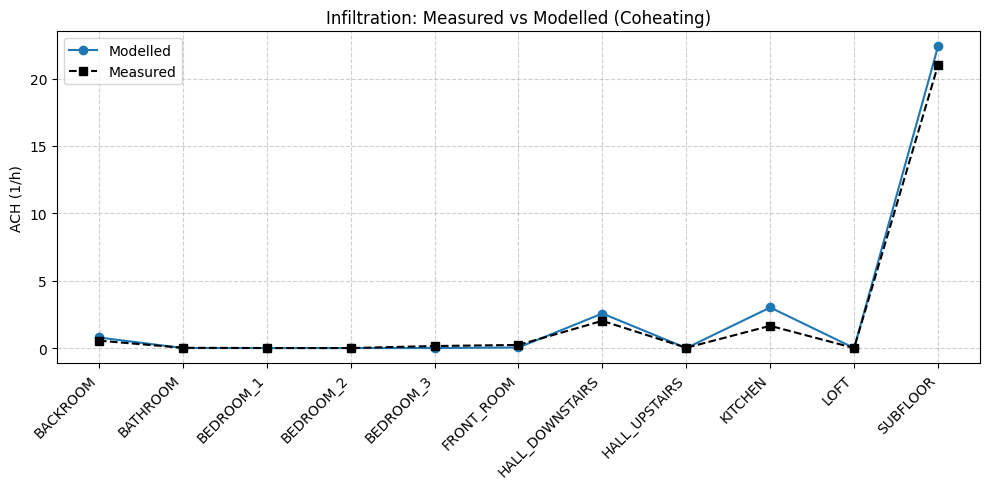

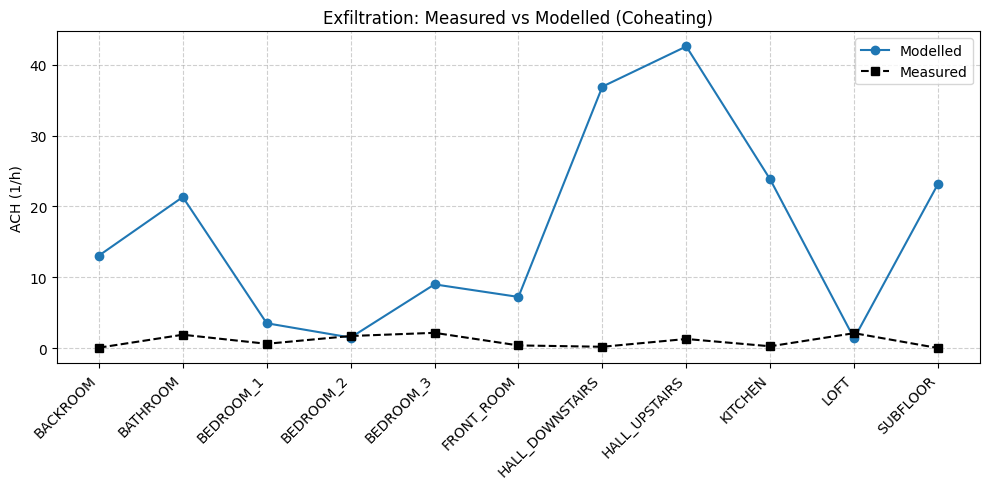

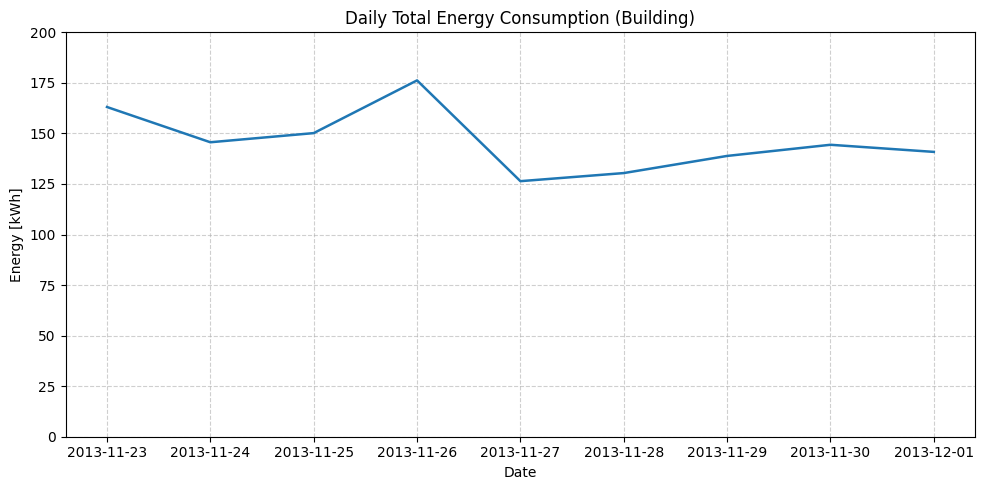

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# --- CONFIGURATION ---
zone_volumes = {
    'HALL_DOWNSTAIRS':19.66,
    'FRONT_ROOM':39.31,
    'KITCHEN':31.75,
    'BACKROOM':31.75,
    'BEDROOM_1':32.21,
    'BEDROOM_2':34.69,
    'BEDROOM_3':19.21,
    'HALL_UPSTAIRS':16.46,
    'BATHROOM':19.89,
    'SUBFLOOR':8.75,
    'LOFT':50.30
}


measured_inf = {"FRONT_ROOM":0.23,"BACKROOM":0.55,"KITCHEN":1.65,"HALL_DOWNSTAIRS":2.02,"HALL_UPSTAIRS":0.02,"BEDROOM_1":0.0,"BEDROOM_2":0.0,"BEDROOM_3":0.15,"BATHROOM":0.02,"SUBFLOOR":21.0,"LOFT":0.0}
measured_exf = {"FRONT_ROOM":0.37,"BACKROOM":0.05,"KITCHEN":0.25,"HALL_DOWNSTAIRS":0.18,"HALL_UPSTAIRS":1.28,"BEDROOM_1":0.6,"BEDROOM_2":1.7,"BEDROOM_3":2.15,"BATHROOM":1.88,"SUBFLOOR":0,"LOFT":2.1}

# --- LOAD + PROCESSING ---
def load_run(path):
    df = pd.read_csv(path)
    dt = df['Date/Time'].str.strip().str.replace('  ', ' ')
    df['datetime'] = pd.to_datetime('2013 ' + dt, format='%Y %m/%d %H:%M:%S', errors='coerce')
    return df.dropna(subset=['datetime']).set_index('datetime')

def compute_infiltration_exfiltration_ach(df, zone_volumes, rho=1.2, cp=1005, dT_min=2):
    out_temp = df.filter(like='Environment:Site Outdoor Air Drybulb Temperature').iloc[:,0]
    zone_temps = df.filter(like='Zone Air Temperature')
    exf_cols = df.filter(like='AFN Zone Exfiltration Sensible Heat Transfer Rate').columns
    inf_cols = df.filter(like='AFN Zone Infiltration Air Change Rate').columns

    exf_ach = pd.DataFrame(index=df.index)
    for col in exf_cols:
        zone = col.split(':')[0]
        if zone in zone_volumes:
            q = df[col]
            tz = zone_temps.filter(like=f'{zone}:').iloc[:,0]
            deltaT = tz - out_temp
            mask = deltaT.abs() > dT_min
            m_dot = (q / (cp * deltaT.abs())).where(mask)
            ach = (m_dot / (rho * zone_volumes[zone])) * 3600
            exf_ach[zone] = ach.clip(lower=0)

    inf_ach = df[inf_cols].copy()
    inf_ach.columns = inf_ach.columns.str.split(':').str[0]
    return inf_ach, exf_ach


def compare_plot(modelled, measured, title):
    zones = sorted(set(measured.keys()) | set(modelled.index))
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(zones, [modelled.get(z, np.nan) for z in zones], 'o-', label="Modelled")
    ax.plot(zones, [measured.get(z, np.nan) for z in zones], 'ks--', label="Measured")
    ax.set(title=title, ylabel="ACH (1/h)")
    plt.xticks(rotation=45, ha="right")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(); plt.tight_layout(); plt.show()

# --- RUN FOR COHEATING OUTPUT ---
coheat_csv = "/workspaces/CUBES/beizaee_validation/coheat/output/eplusout.csv"
df = load_run(coheat_csv)
inf_ach, exf_ach = compute_infiltration_exfiltration_ach(df, zone_volumes)

inf_mean = inf_ach.mean().round(3)
exf_mean = exf_ach.mean().round(3)

print("\n--- Mean Infiltration (ACH) ---")
print(inf_mean.sort_index())
print("\n--- Mean Exfiltration (ACH) ---")
print(exf_mean.sort_index())

compare_plot(inf_mean, measured_inf, "Infiltration: Measured vs Modelled (Coheating)")
compare_plot(exf_mean, measured_exf, "Exfiltration: Measured vs Modelled (Coheating)")



ideal_loads = df.filter(like="IDEALLOAD")

MJ_TO_KWH = 0.277778
J_TO_MJ = 10**-6

daily_total_kwh = ideal_loads.resample('1d').sum().sum(axis=1) * J_TO_MJ * MJ_TO_KWH
plt.figure(figsize=(10,5))
plt.plot(daily_total_kwh.index, daily_total_kwh.values, linewidth=1.8)
plt.title('Daily Total Energy Consumption (Building)')
plt.ylabel('Energy [kWh]')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim([0,200])
plt.tight_layout()
plt.show()
